<a href="https://colab.research.google.com/github/aishujadhav1321/E-commerce-Recommendation-System./blob/main/E_commerce_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS
   UserID  ProductID     ProductName     Category  Rating  PurchaseCount  \
0       1        101       iPhone 14  Electronics       5              3   
1       1        102     AirPods Pro  Electronics       4              2   
2       1        103   Samsung Watch  Accessories       4              1   
3       2        104      Nike Shoes      Fashion       5              4   
4       2        105  Adidas T-Shirt      Fashion       3              2   

   Price  
0  80000  
1  15000  
2  12000  
3   5000  
4   1200  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserID         15 non-null     int64 
 1   ProductID      15 non-null     int64 
 2   ProductName    15 non-null     object
 3   Category       15 non-null     object
 4   Rating         15 non-null     int64 
 5   PurchaseCount  15 non-null     int64 
 6  

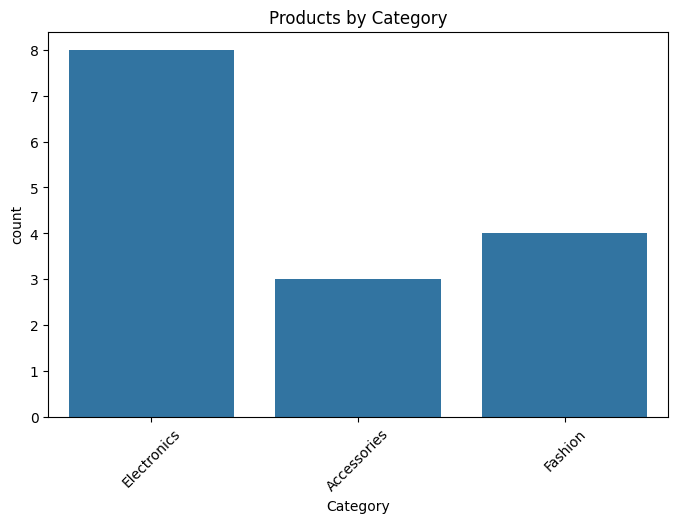


USER PRODUCT MATRIX
ProductName  Adidas T-Shirt  AirPods Pro  Boat Headphones  Dell Laptop  \
UserID                                                                   
1                       0.0          4.0              0.0          0.0   
2                       3.0          0.0              0.0          0.0   
3                       0.0          0.0              0.0          5.0   
4                       0.0          0.0              0.0          0.0   
5                       0.0          0.0              5.0          0.0   

ProductName  Keyboard  Leather Bag  Logitech Mouse  Nike Shoes  Puma Cap  \
UserID                                                                     
1                 0.0          0.0             0.0         0.0       0.0   
2                 0.0          0.0             0.0         5.0       4.0   
3                 4.0          0.0             4.0         0.0       0.0   
4                 0.0          4.0             0.0         0.0       0.0   
5   

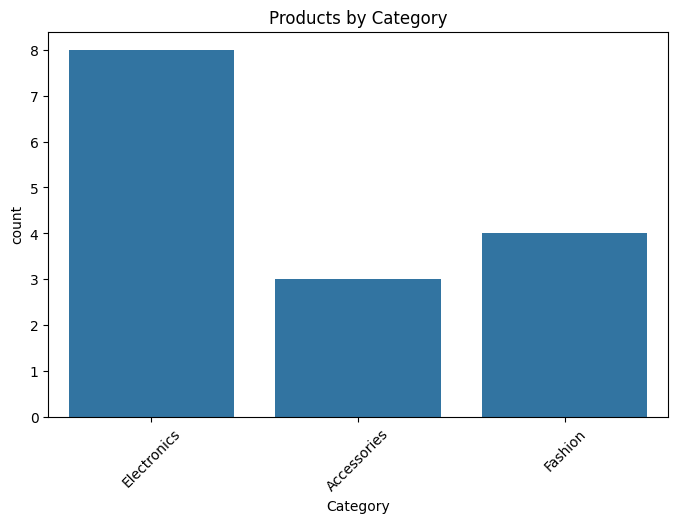

FIRST 5 ROWS
   UserID  ProductID     ProductName     Category  Rating  PurchaseCount  \
0       1        101       iPhone 14  Electronics       5              3   
1       1        102     AirPods Pro  Electronics       4              2   
2       1        103   Samsung Watch  Accessories       4              1   
3       2        104      Nike Shoes      Fashion       5              4   
4       2        105  Adidas T-Shirt      Fashion       3              2   

   Price  
0  80000  
1  15000  
2  12000  
3   5000  
4   1200  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserID         15 non-null     int64 
 1   ProductID      15 non-null     int64 
 2   ProductName    15 non-null     object
 3   Category       15 non-null     object
 4   Rating         15 non-null     int64 
 5   PurchaseCount  15 non-null     int64 
 6  

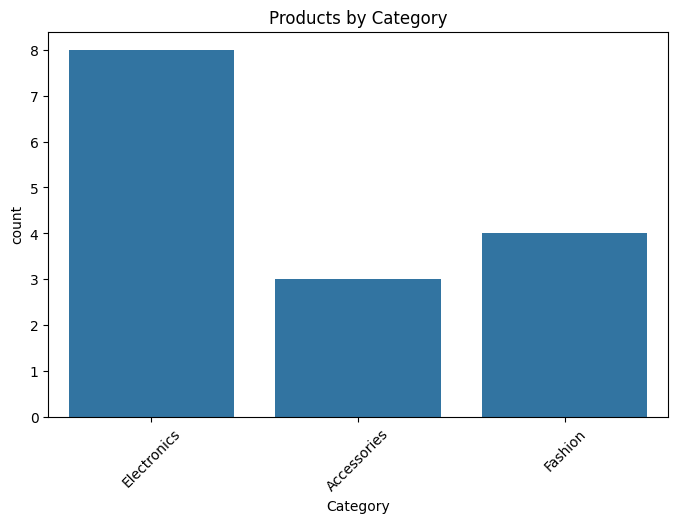


USER PRODUCT MATRIX
ProductName  Adidas T-Shirt  AirPods Pro  Boat Headphones  Dell Laptop  \
UserID                                                                   
1                       0.0          4.0              0.0          0.0   
2                       3.0          0.0              0.0          0.0   
3                       0.0          0.0              0.0          5.0   
4                       0.0          0.0              0.0          0.0   
5                       0.0          0.0              5.0          0.0   

ProductName  Keyboard  Leather Bag  Logitech Mouse  Nike Shoes  Puma Cap  \
UserID                                                                     
1                 0.0          0.0             0.0         0.0       0.0   
2                 0.0          0.0             0.0         5.0       4.0   
3                 4.0          0.0             4.0         0.0       0.0   
4                 0.0          4.0             0.0         0.0       0.0   
5   

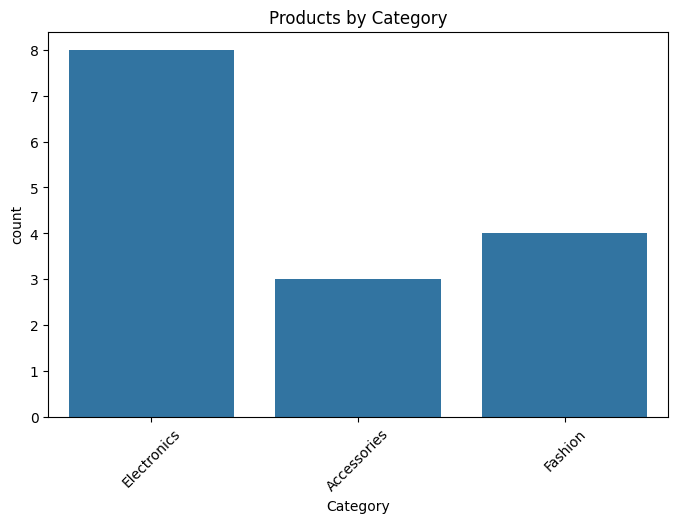

In [2]:
# =========================================
# E-COMMERCE RECOMMENDATION SYSTEM
# COMPLETE PROJECT
# =========================================

# STEP 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

# =========================================
# STEP 2 - LOAD DATASET
# =========================================

df = pd.read_csv("ecommerce_data.csv")

# =========================================
# STEP 3 - VIEW DATA
# =========================================

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

# =========================================
# STEP 4 - REMOVE NULL VALUES
# =========================================

df.dropna(inplace=True)

# =========================================
# STEP 5 - BASIC VISUALIZATION
# =========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Category",
    data=df
)

plt.xticks(rotation=45)

plt.title("Products by Category")

plt.show()

# =========================================
# STEP 6 - USER PRODUCT MATRIX
# =========================================

user_product_matrix = df.pivot_table(
    index='UserID',
    columns='ProductName',
    values='Rating'
).fillna(0)

print("\nUSER PRODUCT MATRIX")
print(user_product_matrix.head())

# =========================================
# STEP 7 - CALCULATE SIMILARITY
# =========================================

similarity = cosine_similarity(
    user_product_matrix
)

similarity_df = pd.DataFrame(
    similarity,
    index=user_product_matrix.index,
    columns=user_product_matrix.index
)

print("\nUSER SIMILARITY MATRIX")
print(similarity_df.head())

# =========================================
# STEP 8 - RECOMMENDATION FUNCTION
# =========================================

def recommend_products(user_id, top_n=5):

    similar_users = similarity_df[user_id].sort_values(
        ascending=False
    )[1:6]

    recommended_products = pd.Series(dtype=float)

    for similar_user in similar_users.index:

        products = user_product_matrix.loc[
            similar_user
        ]

        products = products[products > 0]

        recommended_products = pd.concat(
            [recommended_products, products]
        )

    recommended_products = recommended_products.groupby(
        recommended_products.index
    ).mean()

    products_already_bought = user_product_matrix.loc[
        user_id
    ]

    products_already_bought = products_already_bought[
        products_already_bought > 0
    ].index

    recommended_products = recommended_products.drop(
        products_already_bought,
        errors='ignore'
    )

    recommended_products = recommended_products.sort_values(
        ascending=False
    )

    return recommended_products.head(top_n)

# =========================================
# STEP 9 - TEST RECOMMENDATION
# =========================================

user_id = 1

print(f"\nTOP RECOMMENDATIONS FOR USER {user_id}")

recommendations = recommend_products(user_id)

print(recommendations)

# =========================================
# STEP 10 - MOST POPULAR PRODUCTS
# =========================================

popular_products = df.groupby(
    "ProductName"
)["PurchaseCount"].sum().sort_values(
    ascending=False
)

print("\nMOST POPULAR PRODUCTS")
print(popular_products.head(10))

# =========================================
# STEP 11 - FREQUENTLY BOUGHT PRODUCTS
# =========================================

frequent_products = df.groupby(
    ["Category", "ProductName"]
)["PurchaseCount"].sum()

print("\nFREQUENTLY BOUGHT PRODUCTS")
print(frequent_products.head(10))

# =========================================
# STEP 12 - CONTENT-BASED FILTERING
# =========================================

df["tags"] = (
    df["Category"] + " " +
    df["ProductName"]
)

cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

vectors = cv.fit_transform(
    df["tags"]
).toarray()

content_similarity = cosine_similarity(
    vectors
)

# =========================================
# STEP 13 - SIMILAR PRODUCT FUNCTION
# =========================================

def recommend_similar_products(product_name):

    product_index = df[
        df["ProductName"] == product_name
    ].index[0]

    distances = content_similarity[
        product_index
    ]

    product_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print(f"\nSIMILAR PRODUCTS TO {product_name}")

    for i in product_list:
        print(df.iloc[i[0]].ProductName)

# =========================================
# STEP 14 - TEST SIMILAR PRODUCT
# =========================================

recommend_similar_products(
    df.iloc[0].ProductName
)

# =========================================
# STEP 15 - SAVE OUTPUT FILES
# =========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Category",
    data=df
)

plt.xticks(rotation=45)

plt.title("Products by Category")

plt.savefig("category_distribution.png")

# =========================================
# STEP 16 - SAVE RECOMMENDATIONS
# =========================================

recommendations.to_csv(
    "recommended_products.csv"
)

# =========================================
# STEP 17 - FINAL MESSAGE
# =========================================

print("\nPROJECT COMPLETED SUCCESSFULLY")
print("Output files saved")

In [3]:
recommendations.to_csv(
    "recommended_products.csv"
)

In [4]:
plt.savefig("category_distribution.png")

<Figure size 640x480 with 0 Axes>

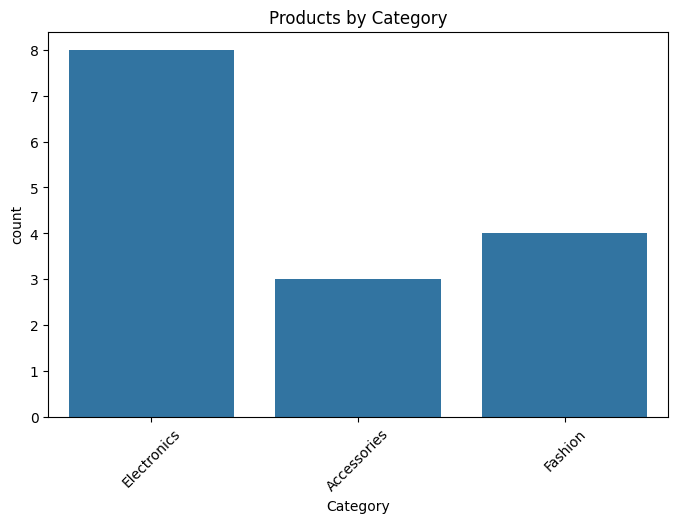

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Category",
    data=df
)

plt.xticks(rotation=45)

plt.title("Products by Category")

plt.savefig("category_distribution.png")

plt.show()

In [7]:
similar_products = pd.DataFrame({
    "Recommended Products": recommendations.index
})

similar_products.to_csv(
    "similar_products.csv",
    index=False
)

In [8]:
df.to_csv(
    "processed_ecommerce_data.csv",
    index=False
)